In [1]:
# Repo setup / imports

import os
import pickle
import zipfile
import warnings
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    roc_auc_score
)
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

REPO_URL = "https://github.com/tongyuguo/HelpHerInvest.git"
REPO_DIR = "HelpHerInvest"

def clone_or_pull():
    """
    Clone the project repository if it does not exist locally.
    Otherwise, pull the latest changes.
    """
    if os.path.isdir(os.path.join(REPO_DIR, ".git")):
        subprocess.run(["git", "-C", REPO_DIR, "pull"], check=False)
    else:
        subprocess.run(["git", "clone", REPO_URL], check=False)

clone_or_pull()

DATA_DIR = os.path.join(REPO_DIR, "Data")
ARTIFACT_DIR = os.path.join(REPO_DIR, "artifacts")
SPLIT_DIR = os.path.join(ARTIFACT_DIR, "data_splits")
MODEL_DIR = os.path.join(ARTIFACT_DIR, "models")
RESULTS_DIR = os.path.join(ARTIFACT_DIR, "results")

os.makedirs(ARTIFACT_DIR, exist_ok=True)
os.makedirs(SPLIT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

STOCKS_CSV = os.path.join(DATA_DIR, "nlp_clean_stock_symbols.csv")
ZIP_PATH = os.path.join(DATA_DIR, "final_dataset_20260224v2.csv.zip")
CSV_IN_ZIP = "final_dataset_20260224v2.csv"

print("Repo directory:", REPO_DIR)
print("Data directory:", DATA_DIR)
print("Artifacts directory:", ARTIFACT_DIR)

Already up to date.
Repo directory: HelpHerInvest
Data directory: HelpHerInvest/Data
Artifacts directory: HelpHerInvest/artifacts


In [2]:
# load_stocks

def load_stocks(path=STOCKS_CSV):
    df = pd.read_csv(path)

    required_cols = ["symbol", "document_clean_tfidf", "document_raw"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in stock NLP file: {missing}")

    # TF-IDF text
    df["kw_text"] = df["document_clean_tfidf"].fillna(df["document_raw"]).fillna("")

    # Embedding text
    df["sem_text"] = df["document_raw"].fillna(df["document_clean_tfidf"]).fillna("")

    # Keep rows with at least one usable text field
    df = df[
        (df["kw_text"].astype(str).str.len() > 0) |
        (df["sem_text"].astype(str).str.len() > 0)
    ].copy()

    # Normalize ticker format
    df["symbol"] = df["symbol"].astype(str).str.upper().str.strip()
    df["kw_text"] = df["kw_text"].astype(str)
    df["sem_text"] = df["sem_text"].astype(str)

    return df.reset_index(drop=True)

df_stocks = load_stocks(STOCKS_CSV)

print("Loaded NLP stock rows:", df_stocks.shape)
print(df_stocks[["symbol", "kw_text", "sem_text"]].head(3))

Loaded NLP stock rows: (10283, 8)
  symbol                                            kw_text  \
0   NVDA  nvidia corp technology semiconductors nvidia c...   
1  GOOGL  alphabet communication services internet conte...   
2   AAPL  apple technology consumer electronics apple de...   

                                            sem_text  
0  NVIDIA CORP Technology Semiconductors NVIDIA C...  
1  Alphabet Inc. Communication Services Internet ...  
2  Apple Inc. Technology Consumer Electronics App...  


In [3]:
# load final zipped dataset

with zipfile.ZipFile(ZIP_PATH) as z:
    df = pd.read_csv(z.open(CSV_IN_ZIP))

if "Ticker" not in df.columns or "Date" not in df.columns or "fwd_excess" not in df.columns:
    raise ValueError("Expected columns Ticker, Date, and fwd_excess are required.")

df["Ticker"] = df["Ticker"].astype(str).str.upper().str.strip()
df["Date"] = pd.to_datetime(df["Date"])

print("Main dataset shape:", df.shape)
print("Unique tickers:", df["Ticker"].nunique())
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("Columns:")
print(df.columns.tolist())

Main dataset shape: (302024, 18)
Unique tickers: 1993
Date range: 2010-02-28 00:00:00 to 2026-02-28 00:00:00
Columns:
['Date', 'Ticker', 'mom_1m', 'mom_3m', 'mom_6m', 'mom_12m', 'mom_12m_ex_1m', 'rel_3m_spy', 'rel_6m_spy', 'rel_12m_spy', 'vol_3m', 'vol_6m', 'drawdown_6m', 'drawdown_12m', 'pct_above_200dma', 'adj_close', 'fwd_excess', 'fwd_return']


In [4]:
# create y

# Binary target:
# 1 if future excess return is positive, 0 otherwise
df = df.copy()
df["y"] = (df["fwd_excess"] > 0).astype(int)

print("Positive fwd_excess count:", (df["fwd_excess"] > 0).sum())
print("Negative fwd_excess count:", (df["fwd_excess"] < 0).sum())
print("Zero fwd_excess count:", (df["fwd_excess"] == 0).sum())

print("\nTarget distribution:")
print(df["y"].value_counts(dropna=False).sort_index())
print(df["y"].value_counts(normalize=True).sort_index())

Positive fwd_excess count: 143948
Negative fwd_excess count: 151730
Zero fwd_excess count: 287

Target distribution:
y
0    158076
1    143948
Name: count, dtype: int64
y
0    0.523389
1    0.476611
Name: proportion, dtype: float64


In [5]:
# create df_rank

# Ranked feature columns from the current notebook structure
rank_cols = [
    "mom_1m", "mom_3m", "mom_6m", "mom_12m", "mom_12m_ex_1m",
    "rel_3m_spy", "rel_6m_spy", "rel_12m_spy",
    "vol_3m", "vol_6m",
    "drawdown_6m", "drawdown_12m",
    "pct_above_200dma"
]

required_for_model = ["Date", "Ticker", "fwd_excess", "y", "adj_close"] + rank_cols
missing_required = [c for c in required_for_model if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns for ranking/modeling: {missing_required}")

# Drop rows only if required model columns are missing
df_model_base = df.dropna(subset=required_for_model).copy()

df_rank = df_model_base.copy()

# Cross-sectional percentile rank by Date
for col in rank_cols:
    df_rank[col] = df_rank.groupby("Date")[col].rank(pct=True)

# Rank the forward excess return by Date
df_rank["fwd_rank"] = df_rank.groupby("Date")["fwd_excess"].rank(pct=True)

# 5-bin label
df_rank["target"] = pd.cut(
    df_rank["fwd_rank"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[0, 1, 2, 3, 4],
    include_lowest=True
)

print("df_rank shape:", df_rank.shape)
print(df_rank.head(3))

df_rank shape: (274511, 21)
            Date Ticker    mom_1m    mom_3m    mom_6m   mom_12m  \
13389 2011-01-31   NVDA  0.997496  0.995826  0.995826  0.814691   
13390 2011-01-31  GOOGL  0.480801  0.142738  0.636060  0.281302   
13391 2011-01-31   AAPL  0.729549  0.623539  0.766277  0.909015   

       mom_12m_ex_1m  rel_3m_spy  rel_6m_spy  rel_12m_spy  ...    vol_6m  \
13389       0.137730    0.995826    0.995826     0.814691  ...  0.928214   
13390       0.276294    0.142738    0.636060     0.281302  ...  0.438230   
13391       0.889816    0.623539    0.766277     0.909015  ...  0.222871   

       drawdown_6m  drawdown_12m  pct_above_200dma  adj_close  fwd_excess  \
13389     0.744157      0.790067          0.995826     0.5483     -0.2287   
13390     0.377295      0.476628          0.515025    14.9114     -0.1585   
13391     0.744157      0.790067          0.747913    10.1670     -0.0330   

       fwd_return  y  fwd_rank  target  
13389     -0.1639  0  0.030050       0  
13390  

In [6]:
# helper functions

def retrieve_features(df):
    """
    Return numeric feature columns for modeling.
    Excludes identifiers, targets, and text fields.
    """
    drop_cols = [
        "Date", "Ticker",
        "fwd_excess", "fwd_return", "y", "fwd_rank", "target",
        "kw_text", "sem_text"
    ]
    feature_cols = [col for col in df.columns if col not in drop_cols]
    feature_cols = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df[col])]
    return feature_cols


def time_split(
    df,
    date_col="Date",
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    sort_dates=True
):
    """
    Chronological split by unique dates.
    Prevents leakage from future dates into training.
    """
    if abs(train_frac + val_frac + test_frac - 1.0) > 1e-8:
        raise ValueError("train_frac + val_frac + test_frac must equal 1.0")

    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col])

    if sort_dates:
        data = data.sort_values(date_col)

    unique_dates = (
        pd.Series(data[date_col].drop_duplicates())
        .sort_values()
        .reset_index(drop=True)
    )

    n_dates = len(unique_dates)
    train_end = int(n_dates * train_frac)
    val_end = int(n_dates * (train_frac + val_frac))

    train_dates = unique_dates.iloc[:train_end]
    val_dates = unique_dates.iloc[train_end:val_end]
    test_dates = unique_dates.iloc[val_end:]

    train_df = data[data[date_col].isin(train_dates)].copy()
    val_df = data[data[date_col].isin(val_dates)].copy()
    test_df = data[data[date_col].isin(test_dates)].copy()

    return train_df, val_df, test_df


def create_confusion_matrix(model, X, y, name):
    """
    Print and plot a confusion matrix.
    """
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)

    cm_df = pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    )

    print(f"\n{name}")
    print(cm_df)

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

    return cm_df

In [7]:
# Merge text and split data

# Merge one text record per ticker onto the ranked modeling data
text_df = (
    df_stocks[["symbol", "kw_text", "sem_text"]]
    .drop_duplicates(subset=["symbol"])
    .rename(columns={"symbol": "Ticker"})
    .copy()
)

# Standardize ticker formatting before merge
text_df["Ticker"] = text_df["Ticker"].astype(str).str.upper().str.strip()

df_model = df_rank.copy()
df_model["Ticker"] = df_model["Ticker"].astype(str).str.upper().str.strip()

# Merge text features onto ranked modeling dataset
df_model = df_model.merge(text_df, on="Ticker", how="left")

# Fill missing text values so downstream NLP steps do not fail
df_model["kw_text"] = df_model["kw_text"].fillna("")
df_model["sem_text"] = df_model["sem_text"].fillna("")

print("Merged modeling dataset shape:", df_model.shape)
print("Share with kw_text:", (df_model["kw_text"].str.len() > 0).mean())
print("Share with sem_text:", (df_model["sem_text"].str.len() > 0).mean())

# Time-based split using the helper already defined earlier
train_df, val_df, test_df = time_split(
    df_model,
    date_col="Date",
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15
)

print("\nSplit dataset shapes:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nDate ranges:")
print("Train:", train_df["Date"].min(), "to", train_df["Date"].max())
print("Validation:", val_df["Date"].min(), "to", val_df["Date"].max())
print("Test:", test_df["Date"].min(), "to", test_df["Date"].max())

Merged modeling dataset shape: (274511, 23)
Share with kw_text: 1.0
Share with sem_text: 1.0

Split dataset shapes:
Train: (176701, 23)
Validation: (47488, 23)
Test: (50322, 23)

Date ranges:
Train: 2011-01-31 00:00:00 to 2021-05-31 00:00:00
Validation: 2021-06-30 00:00:00 to 2023-08-31 00:00:00
Test: 2023-09-30 00:00:00 to 2025-11-30 00:00:00


In [8]:
# Build model features

# Numeric features
numeric_cols = retrieve_features(train_df)

X_train_num = train_df[numeric_cols].reset_index(drop=True)
X_val_num = val_df[numeric_cols].reset_index(drop=True)
X_test_num = test_df[numeric_cols].reset_index(drop=True)

y_train = train_df["y"].reset_index(drop=True)
y_val = val_df["y"].reset_index(drop=True)
y_test = test_df["y"].reset_index(drop=True)

print("Numeric feature count:", len(numeric_cols))

# TF-IDF features, fit only on train text
tfidf = TfidfVectorizer(
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2),
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(train_df["kw_text"].astype(str))
X_val_tfidf = tfidf.transform(val_df["kw_text"].astype(str))
X_test_tfidf = tfidf.transform(test_df["kw_text"].astype(str))

if X_train_tfidf.shape[1] == 0:
    raise ValueError("TF-IDF produced 0 features. Check text coverage in kw_text.")

# Reduce TF-IDF dimension for stability and speed
if X_train_tfidf.shape[1] > 2:
    svd_n = min(50, X_train_tfidf.shape[1] - 1)
    svd = TruncatedSVD(n_components=svd_n, random_state=42)

    X_train_tfidf_red = svd.fit_transform(X_train_tfidf)
    X_val_tfidf_red = svd.transform(X_val_tfidf)
    X_test_tfidf_red = svd.transform(X_test_tfidf)
else:
    svd = None
    X_train_tfidf_red = X_train_tfidf.toarray().astype(np.float32)
    X_val_tfidf_red = X_val_tfidf.toarray().astype(np.float32)
    X_test_tfidf_red = X_test_tfidf.toarray().astype(np.float32)

tfidf_cols = [f"tfidf_feat_{i}" for i in range(X_train_tfidf_red.shape[1])]

X_train_tfidf_df = pd.DataFrame(X_train_tfidf_red, columns=tfidf_cols)
X_val_tfidf_df = pd.DataFrame(X_val_tfidf_red, columns=tfidf_cols)
X_test_tfidf_df = pd.DataFrame(X_test_tfidf_red, columns=tfidf_cols)

print("TF-IDF vocab size:", len(tfidf.vocabulary_))
print("TF-IDF reduced feature count:", len(tfidf_cols))

# SBERT embeddings

def encode_unique_texts(text_series, model, batch_size=128):
    """
    Encode unique texts once, then map back to all rows.
    Saves time when many rows share the same company text.
    """
    text_series = pd.Series(text_series).fillna("").astype(str)
    unique_texts = pd.Index(text_series.unique())

    unique_embeddings = model.encode(
        unique_texts.tolist(),
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True
    ).astype(np.float32)

    lookup = {txt: emb for txt, emb in zip(unique_texts.tolist(), unique_embeddings)}
    all_embeddings = np.vstack(text_series.map(lookup).values)
    return all_embeddings

SBERT_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
sbert_model = SentenceTransformer(SBERT_MODEL_NAME)

E_train = encode_unique_texts(train_df["sem_text"], sbert_model, batch_size=128)
E_val = encode_unique_texts(val_df["sem_text"], sbert_model, batch_size=128)
E_test = encode_unique_texts(test_df["sem_text"], sbert_model, batch_size=128)

print("Raw SBERT embedding dimension:", E_train.shape[1])

# PCA reduction on train only
pca_n = min(32, E_train.shape[1], E_train.shape[0])
pca = PCA(n_components=pca_n, random_state=42)

E_train_red = pca.fit_transform(E_train)
E_val_red = pca.transform(E_val)
E_test_red = pca.transform(E_test)

emb_cols = [f"sbert_feat_{i}" for i in range(E_train_red.shape[1])]

X_train_emb_df = pd.DataFrame(E_train_red, columns=emb_cols)
X_val_emb_df = pd.DataFrame(E_val_red, columns=emb_cols)
X_test_emb_df = pd.DataFrame(E_test_red, columns=emb_cols)

print("Reduced SBERT feature count:", len(emb_cols))

# Final combined feature sets

X_train_all = pd.concat([X_train_num, X_train_tfidf_df, X_train_emb_df], axis=1)
X_val_all = pd.concat([X_val_num, X_val_tfidf_df, X_val_emb_df], axis=1)
X_test_all = pd.concat([X_test_num, X_test_tfidf_df, X_test_emb_df], axis=1)

X_train_all.columns = X_train_all.columns.astype(str)
X_val_all.columns = X_val_all.columns.astype(str)
X_test_all.columns = X_test_all.columns.astype(str)

print("Final X_train shape:", X_train_all.shape)
print("Final X_val shape:", X_val_all.shape)
print("Final X_test shape:", X_test_all.shape)

Numeric feature count: 14


TF-IDF vocab size: 10000
TF-IDF reduced feature count: 50


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Raw SBERT embedding dimension: 384
Reduced SBERT feature count: 32
Final X_train shape: (176701, 96)
Final X_val shape: (47488, 96)
Final X_test shape: (50322, 96)


In [9]:
# Train LightGBM

lgb_model_nlp = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=10,
    num_leaves=31,
    class_weight="balanced",
    random_state=42
)

lgb_model_nlp.fit(
    X_train_all,
    y_train,
    eval_set=[(X_val_all, y_val)],
    eval_metric="binary_logloss",
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(100)
    ]
)

[LightGBM] [Info] Number of positive: 86755, number of negative: 89946
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.118457 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24480
[LightGBM] [Info] Number of data points in the train set: 176701, number of used features: 96
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 100 rounds
[100]	valid_0's binary_logloss: 0.698067
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.693263


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.03
,n_estimators,2000
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20



VALIDATION RESULTS

Validation: Numeric + TF-IDF + SBERT
          Pred 0  Pred 1
Actual 0    7993   16837
Actual 1    7943   14715


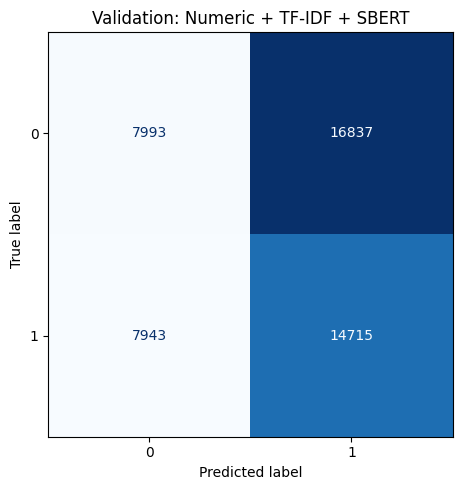

Validation Accuracy: 0.47818396226415094
Validation ROC-AUC: 0.4776106689581306

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.32      0.39     24830
           1       0.47      0.65      0.54     22658

    accuracy                           0.48     47488
   macro avg       0.48      0.49      0.47     47488
weighted avg       0.48      0.48      0.46     47488


TEST RESULTS

Test: Numeric + TF-IDF + SBERT
          Pred 0  Pred 1
Actual 0    8562   18199
Actual 1    8328   15233


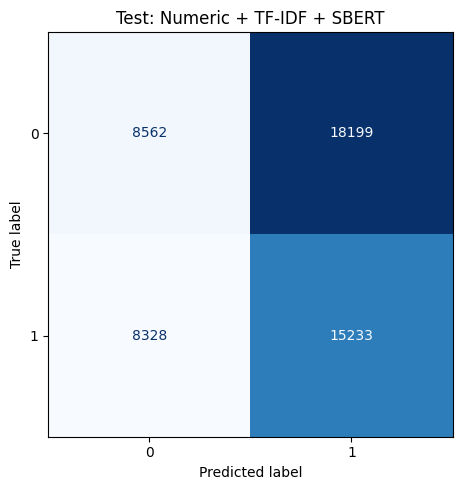

Test Accuracy: 0.47285481499145504
Test ROC-AUC: 0.48531399494985955

Test Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.32      0.39     26761
           1       0.46      0.65      0.53     23561

    accuracy                           0.47     50322
   macro avg       0.48      0.48      0.46     50322
weighted avg       0.48      0.47      0.46     50322


Saved metrics to: HelpHerInvest/artifacts/results/model_metrics.csv
      dataset  accuracy   roc_auc
0  validation  0.478184  0.477611
1        test  0.472855  0.485314


In [10]:
# Evaluate results

# Validation
print("\nVALIDATION RESULTS")
create_confusion_matrix(lgb_model_nlp, X_val_all, y_val, "Validation: Numeric + TF-IDF + SBERT")

val_pred = lgb_model_nlp.predict(X_val_all)
val_prob = lgb_model_nlp.predict_proba(X_val_all)[:, 1]

val_accuracy = accuracy_score(y_val, val_pred)
val_auc = roc_auc_score(y_val, val_prob)

print("Validation Accuracy:", val_accuracy)
print("Validation ROC-AUC:", val_auc)
print("\nValidation Classification Report:")
print(classification_report(y_val, val_pred, zero_division=0))

# Test
print("\nTEST RESULTS")
create_confusion_matrix(lgb_model_nlp, X_test_all, y_test, "Test: Numeric + TF-IDF + SBERT")

test_pred = lgb_model_nlp.predict(X_test_all)
test_prob = lgb_model_nlp.predict_proba(X_test_all)[:, 1]

test_accuracy = accuracy_score(y_test, test_pred)
test_auc = roc_auc_score(y_test, test_prob)

print("Test Accuracy:", test_accuracy)
print("Test ROC-AUC:", test_auc)
print("\nTest Classification Report:")
print(classification_report(y_test, test_pred, zero_division=0))

# Save evaluation results
results_df = pd.DataFrame({
    "dataset": ["validation", "test"],
    "accuracy": [val_accuracy, test_accuracy],
    "roc_auc": [val_auc, test_auc]
})

results_path = os.path.join(RESULTS_DIR, "model_metrics.csv")
results_df.to_csv(results_path, index=False)

print("\nSaved metrics to:", results_path)
print(results_df)

Saved feature importance to: HelpHerInvest/artifacts/results/feature_importance.csv

Top 25 features:
             feature  importance
0          adj_close           5
1      tfidf_feat_33           2
2      tfidf_feat_29           2
3      tfidf_feat_19           2
4       tfidf_feat_7           1
5      tfidf_feat_17           1
6      tfidf_feat_15           1
7       tfidf_feat_8           1
8      tfidf_feat_10           1
9       tfidf_feat_2           1
10     tfidf_feat_28           1
11     tfidf_feat_26           1
12     tfidf_feat_20           1
13      tfidf_feat_4           1
14      tfidf_feat_3           1
15     tfidf_feat_14           1
16     tfidf_feat_46           1
17     tfidf_feat_25           1
18     tfidf_feat_42           1
19     sbert_feat_24           1
20      sbert_feat_4           1
21     sbert_feat_30           1
22     tfidf_feat_48           1
23  pct_above_200dma           0
24      tfidf_feat_1           0


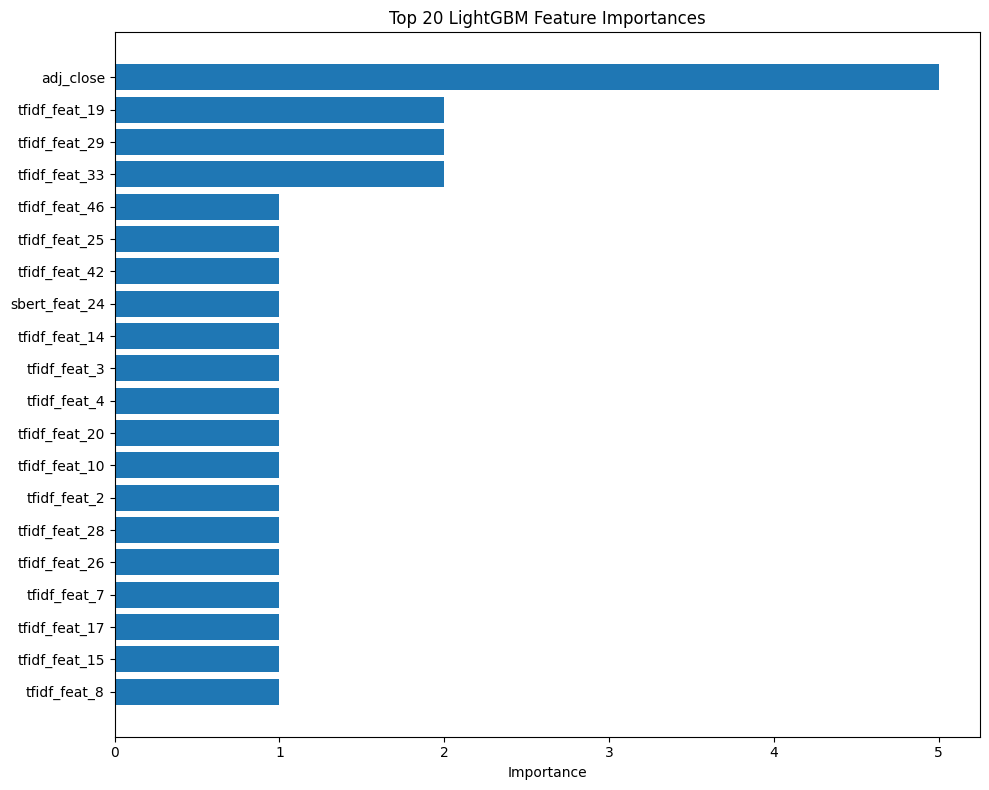

In [11]:
# Feature importance

feature_importance = pd.DataFrame({
    "feature": X_train_all.columns,
    "importance": lgb_model_nlp.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_path = os.path.join(RESULTS_DIR, "feature_importance.csv")
feature_importance.to_csv(importance_path, index=False)

print("Saved feature importance to:", importance_path)
print("\nTop 25 features:")
print(feature_importance.head(25))

plt.figure(figsize=(10, 8))
top_n = 20
plot_df = feature_importance.head(top_n).sort_values("importance", ascending=True)
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Top 20 LightGBM Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [14]:
# Serialize model with pickle

# Save the trained LightGBM model with pickle
model_pickle_path = os.path.join(MODEL_DIR, "lightgbm_nlp_model.pkl")
with open(model_pickle_path, "wb") as f:
    pickle.dump(lgb_model_nlp, f)

print("Saved model pickle to:", model_pickle_path)

# Save preprocessing objects needed for future inference
preprocessing_artifacts = {
    "numeric_cols": numeric_cols,
    "tfidf_vectorizer": tfidf,
    "tfidf_svd": svd,
    "sbert_model_name": SBERT_MODEL_NAME,
    "sbert_pca": pca,
    "final_feature_columns": X_train_all.columns.tolist()
}

preprocess_pickle_path = os.path.join(MODEL_DIR, "preprocessing_artifacts.pkl")
with open(preprocess_pickle_path, "wb") as f:
    pickle.dump(preprocessing_artifacts, f)

print("Saved preprocessing pickle to:", preprocess_pickle_path)


Saved model pickle to: HelpHerInvest/artifacts/models/lightgbm_nlp_model.pkl
Saved preprocessing pickle to: HelpHerInvest/artifacts/models/preprocessing_artifacts.pkl


In [15]:
# Load serialized objects back

# Load the model
with open(model_pickle_path, "rb") as f:
    loaded_model = pickle.load(f)

# Load preprocessing artifacts
with open(preprocess_pickle_path, "rb") as f:
    loaded_preprocessing = pickle.load(f)

print("Loaded model type:", type(loaded_model))
print("Loaded preprocessing keys:", loaded_preprocessing.keys())

# check loaded model predicts successfully
sample_preds = loaded_model.predict(X_test_all.head(5))
print("Sample predictions from loaded model:", sample_preds)

Loaded model type: <class 'lightgbm.sklearn.LGBMClassifier'>
Loaded preprocessing keys: dict_keys(['numeric_cols', 'tfidf_vectorizer', 'tfidf_svd', 'sbert_model_name', 'sbert_pca', 'final_feature_columns'])
Sample predictions from loaded model: [1 1 0 1 1]
